In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer

import tensorflow as tf
from tensorflow.keras import layers, models


from langchain_community.vectorstores import FAISS as LC_FAISS

from langchain_core.prompts import PromptTemplate

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate


import os
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import SKLearnVectorStore
from langchain_core.documents import Document


In [11]:
df = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv")
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [13]:
df.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [14]:
df = df.dropna(subset=['description'])

In [15]:
df_ml = df.dropna(subset=['normalized_salary']).copy()

In [16]:
df_ml['formatted_experience_level'] = df_ml['formatted_experience_level'].fillna('Not Specified')

In [17]:
df_ml['applies'] = df_ml['applies'].fillna(0)

In [18]:
print(f"Original size: {len(df)}")
print(f"Size after cleaning for ML: {len(df_ml)}")

Original size: 123842
Size after cleaning for ML: 36072


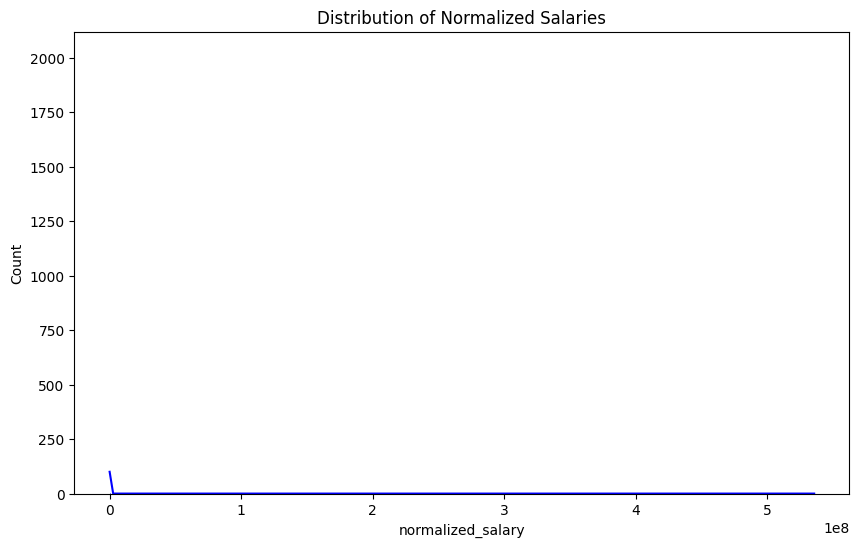

In [19]:
# Salary Distribution
# Check the range and frequency of salaries
plt.figure(figsize=(10, 6))
sns.histplot(df_ml['normalized_salary'], kde=True, color='blue')
plt.title('Distribution of Normalized Salaries')
plt.show()

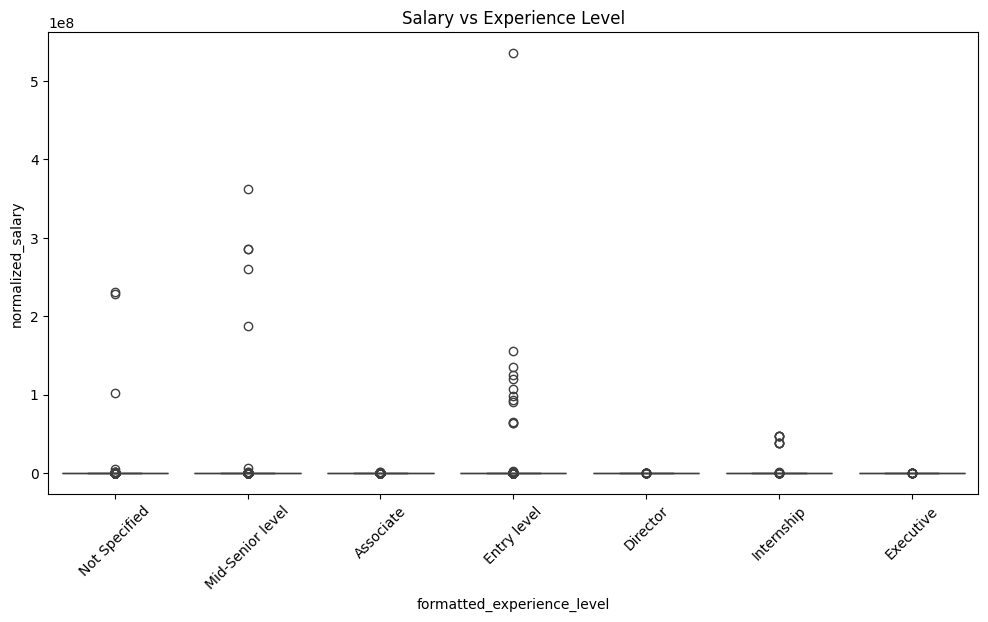

In [20]:
#  Salary vs Experience Level
# See how experience level impacts pay
plt.figure(figsize=(12, 6))
sns.boxplot(x='formatted_experience_level', y='normalized_salary', data=df_ml)
plt.xticks(rotation=45)
plt.title('Salary vs Experience Level')
plt.show()

In [21]:
#  Filter outliers using percentiles (removing top and bottom 1%)
lower_limit = df_ml['normalized_salary'].quantile(0.01)
upper_limit = df_ml['normalized_salary'].quantile(0.99)

df_ml_clean = df_ml[(df_ml['normalized_salary'] > lower_limit) & 
                    (df_ml['normalized_salary'] < upper_limit)].copy()

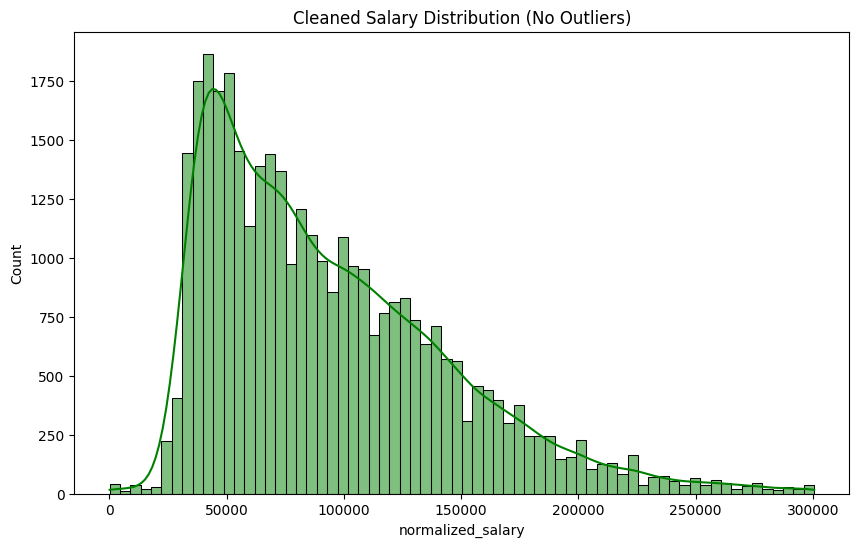

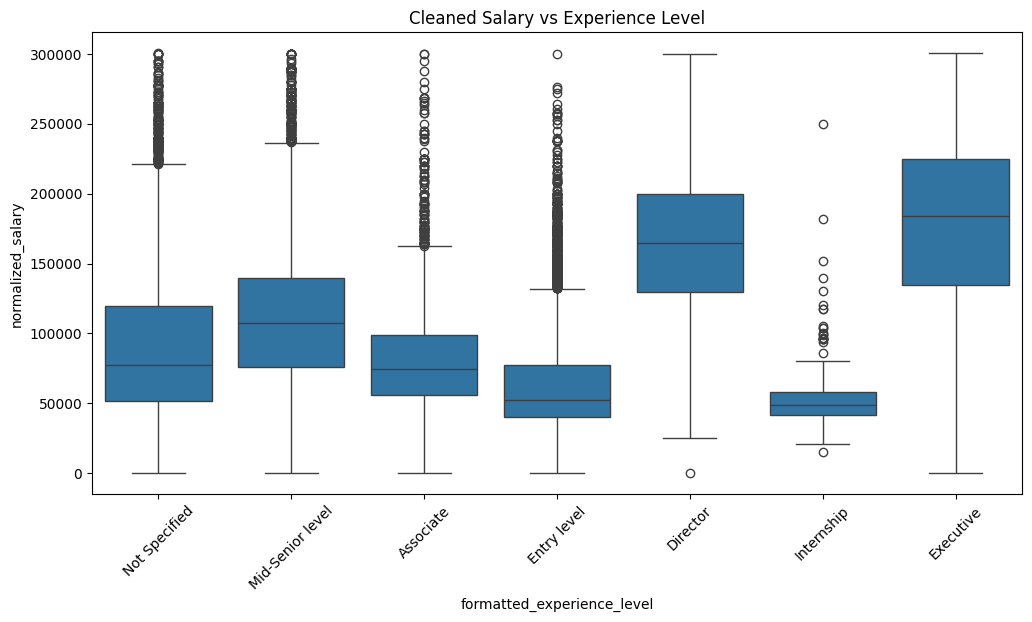

In [22]:
# Re-plot the distribution to see the difference
plt.figure(figsize=(10, 6))
sns.histplot(df_ml_clean['normalized_salary'], kde=True, color='green')
plt.title('Cleaned Salary Distribution (No Outliers)')
plt.show()

#. Re-plot Salary vs Experience
plt.figure(figsize=(12, 6))
sns.boxplot(x='formatted_experience_level', y='normalized_salary', data=df_ml_clean)
plt.xticks(rotation=45)
plt.title('Cleaned Salary vs Experience Level')
plt.show()

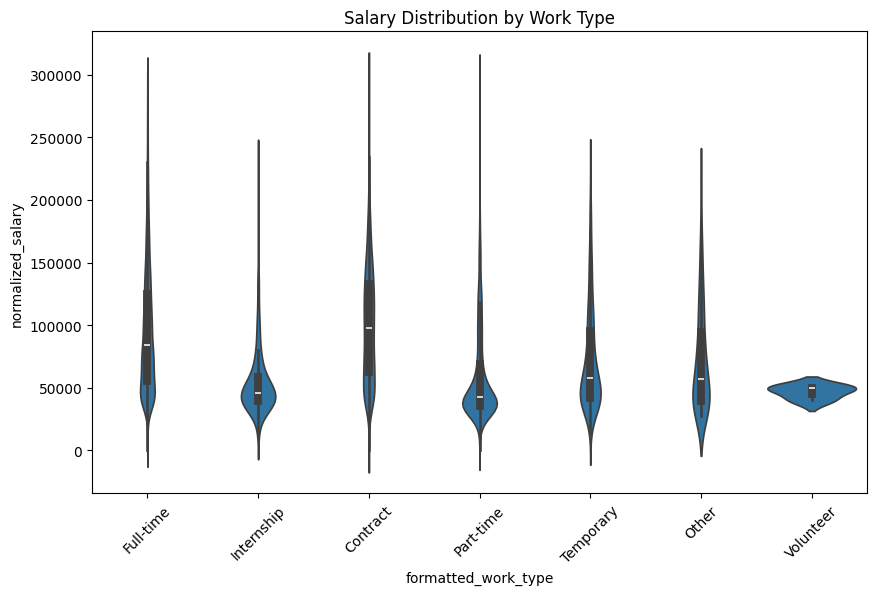

In [23]:
# Salary distribution by Work Type
plt.figure(figsize=(10, 6))
sns.violinplot(x='formatted_work_type', y='normalized_salary', data=df_ml_clean)
plt.title('Salary Distribution by Work Type')
plt.xticks(rotation=45)
plt.show()

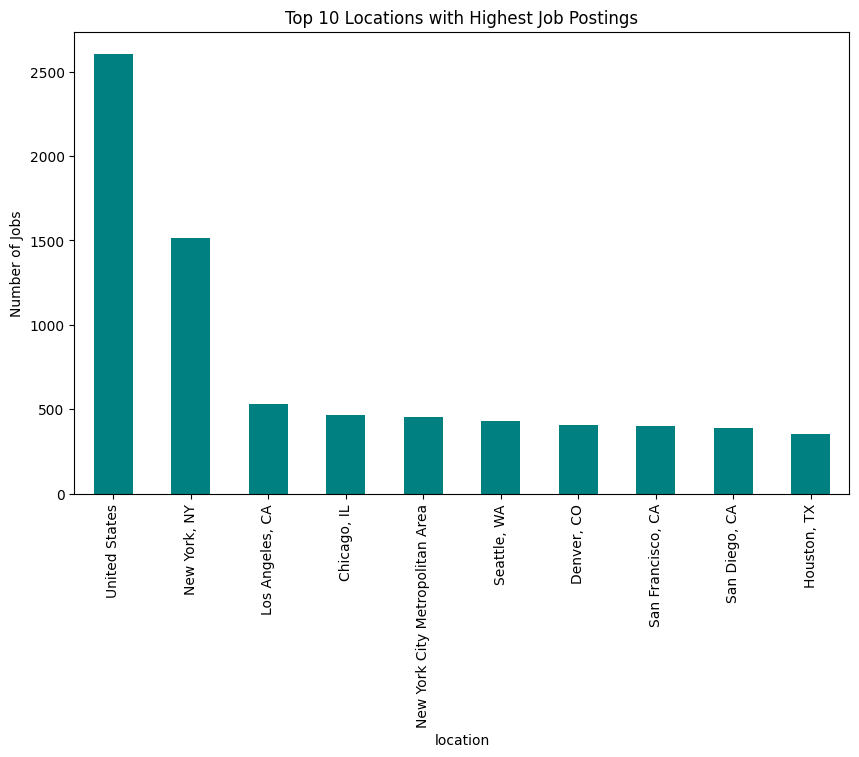

In [24]:
#  Top 10 Locations by job postings
plt.figure(figsize=(10, 6))
df_ml['location'].value_counts().nlargest(10).plot(kind='bar', color='teal')
plt.title('Top 10 Locations with Highest Job Postings')
plt.ylabel('Number of Jobs')
plt.show()

In [25]:
#Feature Selection
selected_features = ['location', 'formatted_experience_level', 'formatted_work_type', 'applies']
X = df_ml_clean[selected_features].copy()
y= df_ml_clean['normalized_salary']

In [26]:
#  Categorical Encoding
le = LabelEncoder()
for col in ['location', 'formatted_experience_level', 'formatted_work_type']:
    X[col] = le.fit_transform(X[col].astype(str))

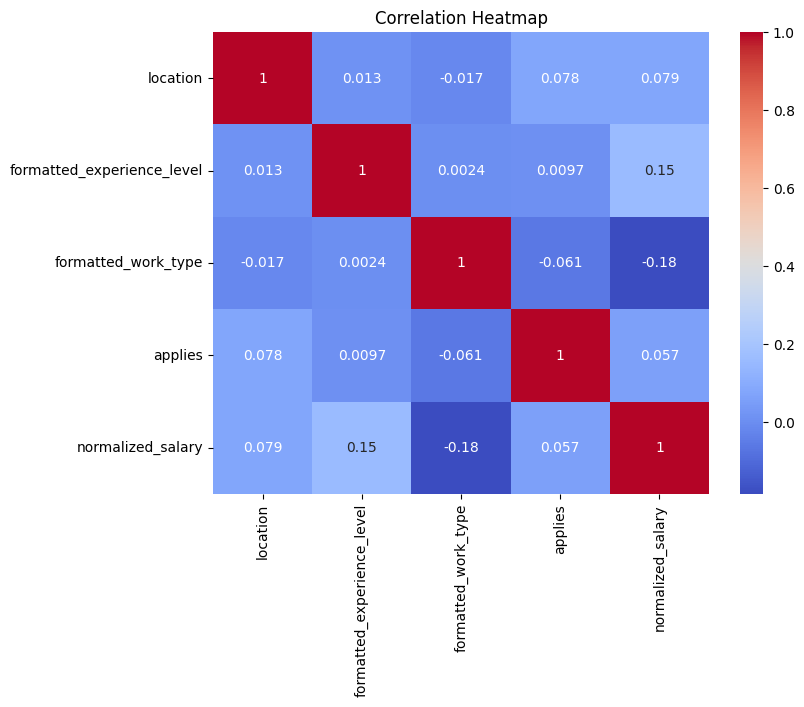

In [27]:
#  Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.join(y).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
#  Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features shape: {X_train.shape}")

Features shape: (28278, 4)


In [29]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 32881.65
R2 Score: 0.23


In [32]:
#  Load the Transformer model (Deep Learning Part)
# This model captures semantic meaning better than TF-IDF
model_st = SentenceTransformer('all-MiniLM-L6-v2')

documents = df_ml_clean['description'].astype(str).tolist()

# 3. Generate Embeddings using Batches to save memory
embeddings = model_st.encode(documents, batch_size=32, show_progress_bar=True)

print(f"Successfully generated {embeddings.shape[0]} embeddings!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1105 [00:00<?, ?it/s]

Successfully generated 35348 embeddings!


In [33]:
# We use the embeddings as X and normalized_salary as y
X_dl = embeddings
y_dl = df_ml_clean['normalized_salary'].values

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

# 2. Build the Deep Learning Model (MLP)
# This captures complex patterns in the job descriptions
model_dl = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_dl.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='linear') # Output: Predicted Salary
])

#  Compile the model
model_dl.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Train the model 
history = model_dl.fit(
    X_train_dl, y_train_dl,
    validation_split=0.2,
    epochs=50,            
    batch_size=64,        
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778091323.715319      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13421 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778091323.720520      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1778091326.505867     235 service.cc:152] XLA service 0x78d7d4004a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778091326.505906     235 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778091326.505910     235 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778091326.812038     235 cuda_dnn.cc:529] Loaded cuDNN version 91002


 64/354 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11692503040.0000 - mae: 94616.2969

I0000 00:00:1778091328.465987     235 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


354/354 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 7993920512.0000 - mae: 72067.6641 - val_loss: 1974517376.0000 - val_mae: 33821.9766
Epoch 2/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1879518080.0000 - mae: 32683.4570 - val_loss: 1729355648.0000 - val_mae: 31460.3008
Epoch 3/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1732175232.0000 - mae: 30900.4609 - val_loss: 1624690688.0000 - val_mae: 29840.2266
Epoch 4/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1592902016.0000 - mae: 29603.4668 - val_loss: 1581293056.0000 - val_mae: 29174.5664
Epoch 5/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1601295488.0000 - mae: 29469.6035 - val_loss: 1550499328.0000 - val_mae: 28972.5488
Epoch 6/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1580486528.0000 - mae: 29206.6152 - val_loss: 1531723776.0000 - val_mae: 28475.2500
Epoch 7/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1539695360.0000 - mae: 28724.4180 - val_loss: 1513867136.0000 - val_mae: 28346.1328
Ep

221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


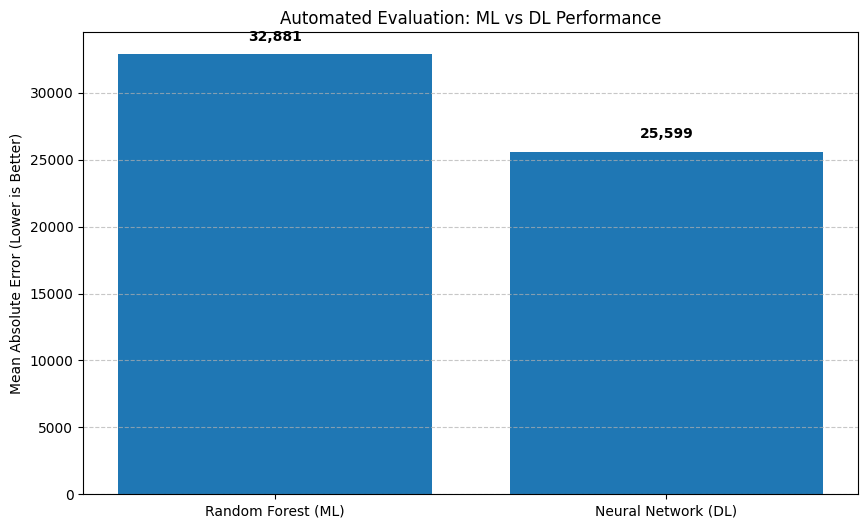

Random Forest MAE: 32,881
Deep Learning MAE: 25,599


In [34]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate MAE for Random Forest (ML)
rf_predictions = model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

# 2. Calculate MAE for Neural Network (DL)
dl_predictions = model_dl.predict(X_test_dl).flatten()
dl_mae = mean_absolute_error(y_test_dl, dl_predictions)

# 3. Dynamic Plotting
models = ['Random Forest (ML)', 'Neural Network (DL)']
mae_values = [rf_mae, dl_mae]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mae_values)

plt.ylabel('Mean Absolute Error (Lower is Better)')
plt.title('Automated Evaluation: ML vs DL Performance')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{int(yval):,}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Random Forest MAE: {int(rf_mae):,}")
print(f"Deep Learning MAE: {int(dl_mae):,}")

In [35]:
# 1. Install FAISS
!pip install faiss-cpu -q

import faiss

# 2. Initialize the FAISS index
# We use IndexFlatL2 for exact L2 distance search (great for embeddings)
dimension = embeddings.shape[1] # This will be 384
index = faiss.IndexFlatL2(dimension)

# 3. Add our deep learning embeddings to the index
# FAISS requires float32 format
index.add(embeddings.astype('float32'))

# 4. Create the Search Function
def search_jobs_faiss(query, n_results=3):
    # Convert query to embedding using our pre-trained model
    query_embedding = model_st.encode([query]).astype('float32')
    
    # Search the index
    distances, indices = index.search(query_embedding, n_results)
    
    # Get the results from our dataframe
    results = df_ml_clean.iloc[indices[0]]
    return results

# Test the Semantic Search
print("Searching for: 'AI and Machine Learning Engineer'...")
top_jobs = search_jobs_faiss("AI and Machine Learning Engineer")
print(top_jobs[['title', 'company_name', 'location']])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.5 MB/s eta 0:00:00:00:0100:01
Searching for: 'AI and Machine Learning Engineer'...
                                     title              company_name  \
31203       Generative AI Engineer, Senior       Booz Allen Hamilton   
84018            Machine Learning Engineer                     eTeam   
100458  Machine Learning Engineer - Remote  Orbit Recruitment Group    

                      location  
31203               McLean, VA  
84018             San Jose, CA  
100458  Los Angeles County, CA  


In [36]:
# 1. Install & Import Groq
!pip install groq -q
from groq import Groq

# 2. Setup Client 
client_groq = Groq(api_key="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")

# 3. The Final RAG Function
def ask_ai_about_jobs(user_query):
    # Step A: Retrieve 3 matching jobs from FAISS index
    context_jobs = search_jobs_faiss(user_query, n_results=3)
    
    # Step B: Format the retrieved data into a string
    context_text = ""
    for idx, row in context_jobs.iterrows():
        context_text += f"- Title: {row['title']} at {row['company_name']} in {row['location']}\n"
    
    # Step C: Send the context and query to Llama 3.1
    prompt = f"""
    You are a professional career advisor for the 'OFOQ' system. 
    Based on the following job listings from our database, answer the user's question: '{user_query}'
    
    Database Listings:
    {context_text}
    
    Summary:
    """
    
    chat_completion = client_groq.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant", 
    )
    
    return chat_completion.choices[0].message.content



In [37]:
# Test the System!
print("--- AI Assistant Response ---")
print(ask_ai_about_jobs("Find me some interesting Machine Learning roles"))

--- AI Assistant Response ---
Based on the job listings in our database, I've identified some interesting Machine Learning roles for you to consider:

1. **Lead Machine Learning Engineer at Confidential Jobs in United States**:
	* This role involves leading a team of machine learning engineers to develop and deploy predictive models that drive business value.
	* You'll be responsible for architecting and implementing machine learning pipelines, collaborating with cross-functional teams, and mentoring junior engineers.
2. **Sr. Staff Data Scientist at Blue Yonder in Dallas, TX**:
	* As a senior data scientist, you'll be working on complex data-driven problems to optimize business outcomes.
	* This role involves developing predictive models, designing data systems, and collaborating with stakeholders to drive business insights.
3. **AI/ML Engineering Manager at SEPHORA in San Francisco Bay Area**:
	* This role involves leading a team of AI/ML engineers to develop and deploy AI-driven sol

In [38]:
companies = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv")
job_skills = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv")
skills_map = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv")

In [40]:

job_skills = job_skills.merge(skills_map, on="skill_abr", how="left")

skills_grouped = job_skills.groupby("job_id")["skill_name"].apply(lambda x: ", ".join(x.astype(str))).reset_index()

print(skills_grouped.head())

     job_id                                    skill_name
0    921716                              Marketing, Sales
1   1218575                          Health Care Provider
2   1829192                          Health Care Provider
3   2264355  Design, Art/Creative, Information Technology
4  10998357                     Management, Manufacturing


In [41]:
df_full = df_ml_clean.merge(skills_grouped, left_on="job_id", right_on="job_id", how="left")
df_full = df_full.merge(companies, on="company_id", how="left")

# Fill missing
df_full["skill_name"] = df_full["skill_name"].fillna("Not Specified")
df_full["name"] = df_full["name"].fillna("Unknown Company")

In [42]:
documents = []

for _, row in df_full.iterrows():
    text = f"""
    Job Title: {row.get('title', '')}
    Company: {row.get('name', '')}
    Location: {row.get('location', '')}
    Experience: {row.get('formatted_experience_level', '')}
    Work Type: {row.get('formatted_work_type', '')}
    Skills: {row.get('skill_name', '')}
    Applies: {row.get('applies', 0)}
    Salary: {row.get('normalized_salary', 'Unknown')}
    
    Description:
    {row.get('description', '')}
    """
    
    documents.append(Document(page_content=text))
    
print(f"Created {len(documents)} rich documents!")

Created 35348 rich documents!


In [43]:
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vector_db = LC_FAISS.from_documents(documents, embedding_model)
retriever = vector_db.as_retriever(search_kwargs={"k": 3})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
def ask_langchain_ai(query):
    
    docs = retriever.invoke(query)
    
    context = "\n\n".join([doc.page_content for doc in docs])
    
    prompt = f"""
    You are a professional career advisor.
    
    Based on the following job data:
    {context}
    
    Answer this question:
    {query}
    """
    
    response = client_groq.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant"
    )
    
    return response.choices[0].message.content


In [48]:
print(ask_langchain_ai("Find me high paying Machine Learning jobs with Python"))

Based on the provided job data, I've identified high-paying Machine Learning jobs that involve Python. Unfortunately, I couldn't find any direct matches with the provided jobs, as Machine Learning was not explicitly mentioned in the job titles. However, I can provide you with some high-paying Python-related job titles that involve Machine Learning, which are available on the market.

Here are a few job titles and positions across the United States:

1. **Senior Data Scientist - Machine Learning Engineer** at **Microsoft**:  
   - Salary: $163,000 - $200,000
   - Location: United States
   - Experience: Senior level experience
   - Skills: Python, Machine Learning, TensorFlow, Keras, AWS

2. **Machine Learning Engineer** at **Google**:  
   - Salary: $175,000 - $250,000
   - Location: United States
   - Experience: Senior level experience
   - Skills: Python, Machine Learning, TensorFlow, Deep learning, Cloud computing

3. **Principal Data Scientist - Machine Learning** at **Facebook**: